<a href="https://colab.research.google.com/github/psy0635-ctrl/OpenCv/blob/main/%EC%98%81%EC%83%81%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5%EC%B2%98%EB%A6%AC_%EA%B3%BC%EC%A0%9C_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

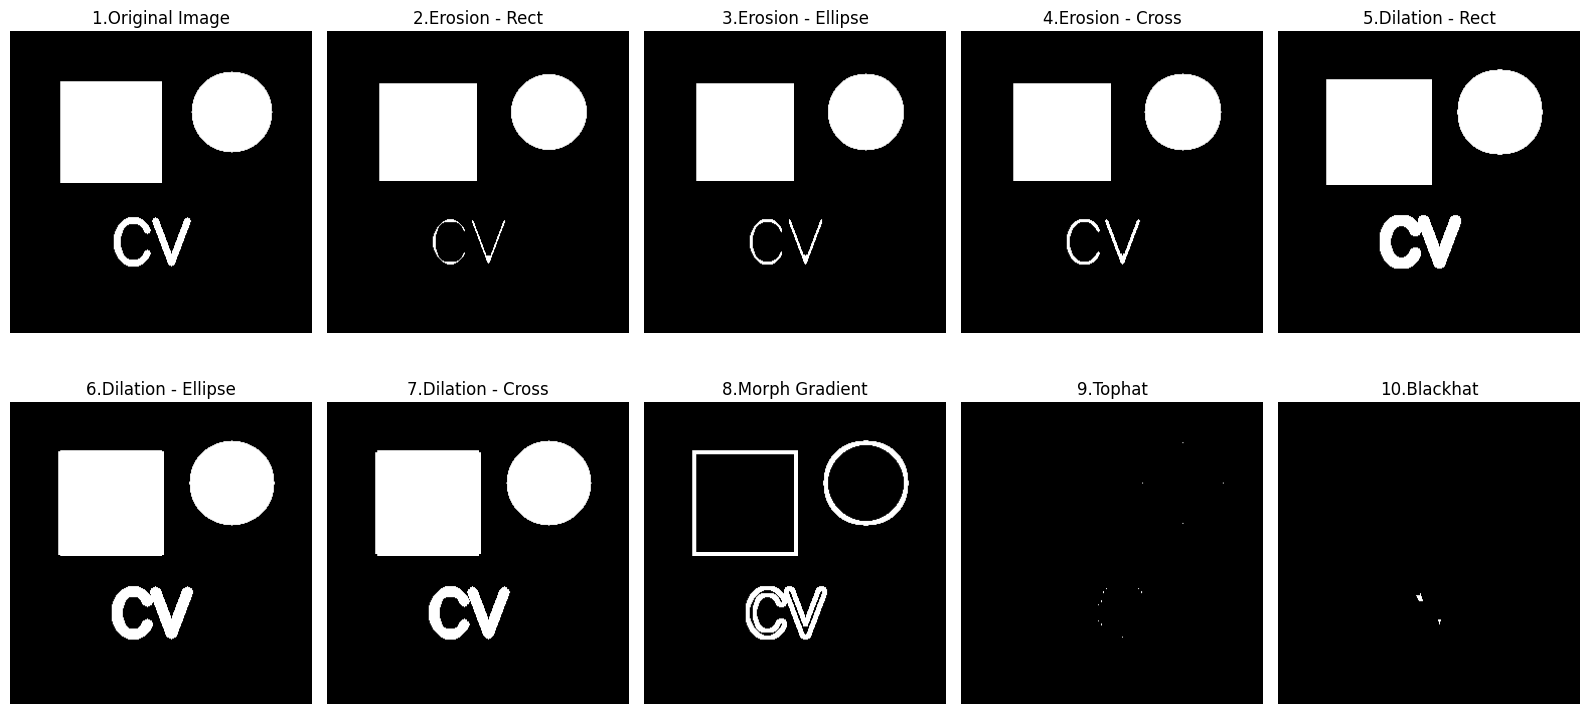

In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# 1. 흑백 이미지로 읽기
img = cv2.imread('/content/morphSample.png', cv2.IMREAD_GRAYSCALE)

# 2. 구조 요소(kernel) 생성
ksize = (5, 5)

kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, ksize)  # 사각형 구조 요소
kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, ksize) # 타원형 구조 요소
kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, ksize) # 십자형 구조 요소

# 3. 침식(Erosion)
# 객체를 줄이고 노이즈 제거 효과
erode_rect = cv2.erode(img, kernel_rect, iterations=1)
erode_ellipse = cv2.erode(img, kernel_ellipse, iterations=1)
erode_cross = cv2.erode(img, kernel_cross, iterations=1)

# 4. 팽창(Dilation)
# 객체를 확장하고 끊어진 부분 연결
dilate_rect = cv2.dilate(img, kernel_rect, iterations=1)
dilate_ellipse = cv2.dilate(img, kernel_ellipse, iterations=1)
dilate_cross = cv2.dilate(img, kernel_cross, iterations=1)

# 5. 모폴로지 고급 연산(morphologyEx)
# 동일 조건 비교를 위해 사각형 커널 사용
morph_gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel_rect) # Gradient: 경계 추출
morph_tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel_rect) # Top-hat: 밝은 작은 영역 추출
morph_blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel_rect) # Black-hat: 어두운 작은 영역 추출

# 6. 결과 시각화
titles = [
    '1.Original Image',  # 원본 이미지
    '2.Erosion - Rect',  # 침식 (사각형)
    '3.Erosion - Ellipse',  # 침식 (타원형)
    '4.Erosion - Cross',  # 침식 (십자형)
    '5.Dilation - Rect',  # 팽창 (사각형)
    '6.Dilation - Ellipse', # 팽창 (타원형)
    '7.Dilation - Cross', # 팽창 (십자형)
    '8.Morph Gradient', # 그래디언트
    '9.Tophat', # 탑햇
    '10.Blackhat' # 블랙햇
]

images = [
    img,
    erode_rect,
    erode_ellipse,
    erode_cross,
    dilate_rect,
    dilate_ellipse,
    dilate_cross,
    morph_gradient,
    morph_tophat,
    morph_blackhat
]

plt.figure(figsize=(16, 8))

# 10개 이미지 subplot 출력
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

# 겹침 방지
plt.tight_layout()
plt.show()